# Australia fires:

## 1) Analyze correlations between IOD/ENSO/SAM and Australia rains

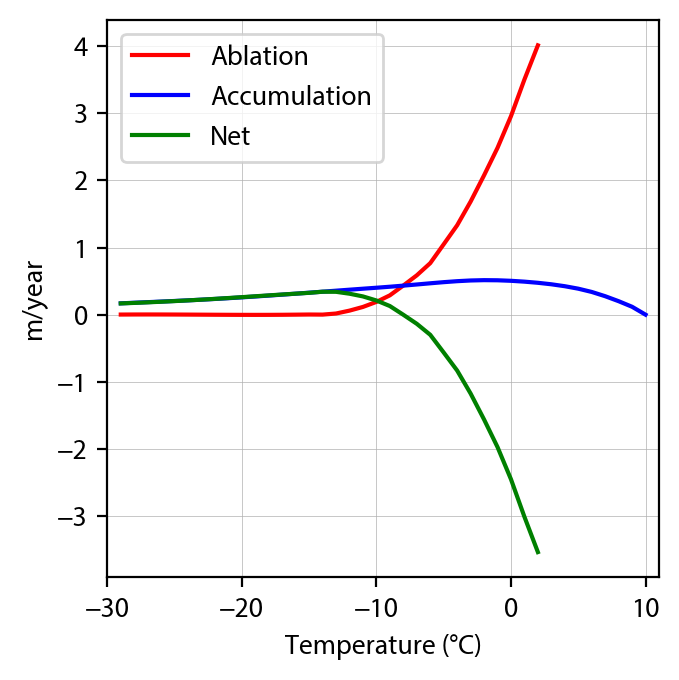

In [9]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate
from numpy import linalg
import scipy as scipy


# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'


#%matplotlib widget
# Import the csv datasets:
# -----------------------
dataset = pd.read_csv('ablation.csv'\
            ,sep=',',na_values='NaN',comment='#',skipinitialspace=False,skip_blank_lines=False,header=None)
data = np.asarray(dataset.iloc[:, :].values,dtype='float')
T_ablation=data[:,0]
ablation=data[:,1]

dataset = pd.read_csv('accumulation.csv'\
            ,sep=',',na_values='NaN',comment='#',skipinitialspace=False,skip_blank_lines=False,header=None)
data = np.asarray(dataset.iloc[:, :].values,dtype='float')
T_accumulation=data[:,0]
accumulation=data[:,1]

T_highres=np.arange(-30,12,1)
ablation_highres=interpolate.griddata(T_ablation, ablation, T_highres, method='cubic')
accumulation_highres=interpolate.griddata(T_accumulation, accumulation, T_highres, method='cubic')
net=accumulation_highres-ablation_highres


fig=plt.figure(figsize=(3.5,3.5),dpi=200)
plt.plot(T_highres,ablation_highres,color="r",label="Ablation")
plt.plot(T_highres,accumulation_highres,color="b",label="Accumulation")
plt.plot(T_highres,net,color="g",label="Net")
plt.grid(lw=0.25)
plt.xlim(-30,11)
plt.xlabel("Temperature (°C)")
plt.ylabel("m/year")
plt.legend()
plt.tight_layout()
fig.savefig("Output/ice-sheets-Oerlemans91_SMB_schematic.pdf")

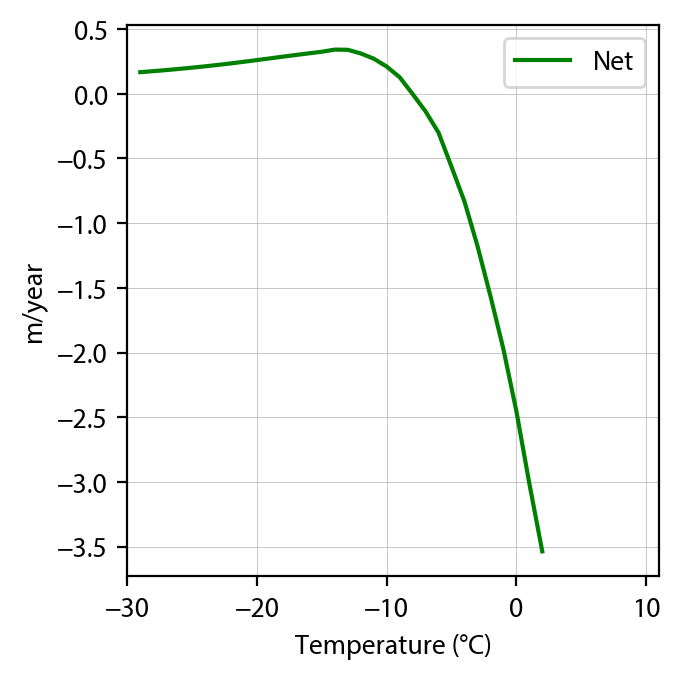

In [10]:
# and now only the net, for the course slides:
fig=plt.figure(figsize=(3.5,3.5),dpi=200)
plt.plot(T_highres,net,color="g",label="Net")
plt.grid(lw=0.25)
plt.xlim(-30,11)
plt.xlabel("Temperature (°C)")
plt.ylabel("m/year")
plt.legend()
plt.tight_layout()
fig.savefig("Output/ice-sheets-Oerlemans91_SMB_schematic_net_only.pdf")